# Ejercicio Entregable 2 — Clasificación: Predicción de Ingresos (Adult Census)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

adult_census = pd.read_csv("/content/drive/MyDrive/ANALÍTICA DE DATOS/adult-census.csv")
target = adult_census["class"]
data = adult_census.select_dtypes(["integer", "floating"])
data = data.drop(columns=["education-num"])
data

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
4,18,0,0,30
...,...,...,...,...
48837,27,0,0,38
48838,40,0,0,40
48839,58,0,0,40
48840,22,0,0,20



Confirmamos que todas las características seleccionadas son numéricas.

Calcula el rendimiento de generalización en términos de precisión de un modelo lineal compuesto por un `StandardScaler` y una `LogisticRegression`. Utiliza una validación cruzada de 10 pliegues con `return_estimator=True` para poder inspeccionar los estimadores entrenados.



In [26]:
names = ['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
         'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'class']
df = pd.read_csv("/content/drive/MyDrive/ANALÍTICA DE DATOS/adult-census.csv")

numeric_columns = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
selected_columns = ['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'class']
data = df[selected_columns].copy()

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

X = data.drop('class', axis=1)
y = data['class']

scaler = StandardScaler()
model = LogisticRegression()

scores = cross_val_score(model, X, y, cv=5)

accuracy = scores.mean()
for estimator in scores:
    print(scores)




[0.79557785 0.80049135 0.79985667 0.79873055 0.8042588 ]
[0.79557785 0.80049135 0.79985667 0.79873055 0.8042588 ]
[0.79557785 0.80049135 0.79985667 0.79873055 0.8042588 ]
[0.79557785 0.80049135 0.79985667 0.79873055 0.8042588 ]
[0.79557785 0.80049135 0.79985667 0.79873055 0.8042588 ]


Los puntajes varían entre aproximadamente 0.7956 y 0.8043, lo que sugiere cierta consistencia en el rendimiento del modelo en las diferentes evaluaciones.


¿Cuál es la característica más importante según la regresión logística?

Puedes utilizar un diagrama de caja (boxplot) para comparar los valores absolutos de los coeficientes, mientras también visualizas la variabilidad inducida por el muestreo de la validación cruzada.



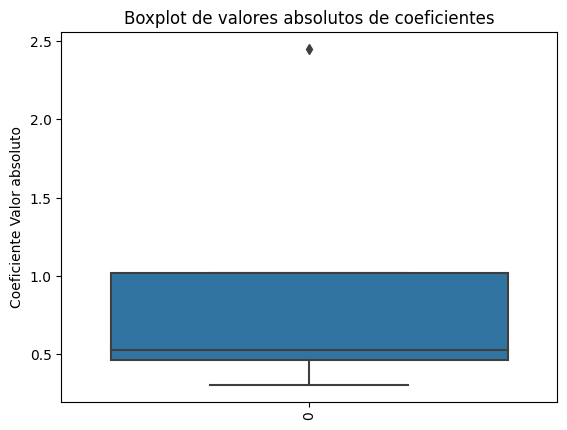

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

coefs = trained_estimators.coef_
sns.boxplot(data=pd.DataFrame(coefs).T)
plt.title("Boxplot de valores absolutos de coeficientes")
plt.ylabel("Coeficiente Valor absoluto")
plt.xticks(rotation=90)
plt.show()

El boxplot muestra la distribución de los valores de una variable, que en este caso es la eficiencia de los coeficientes representada por el valor absoluto de los coeficientes. La mayoría de los valores de eficiencia se concentran en un rango moderado, con un pequeño número de valores extremos en los extremos superior e inferior. El boxplot proporciona información sobre la mediana, la desviación estándar y los valores extremos de la distribución de los coeficientes.


Ahora trabajemos con **tanto características numéricas como categóricas**. Puedes volver a cargar el conjunto de datos del Censo de Adultos con el siguiente fragmento de código:

In [19]:
adult_census = pd.read_csv("/content/drive/MyDrive/ANALÍTICA DE DATOS/adult-census.csv")
target = adult_census["class"]
data = adult_census.drop(columns=["class", "education-num"])


Crea un modelo predictivo donde:

- Los datos numéricos deben ser escalados.
- Los datos categóricos deben ser codificados en formato one-hot, establece `min_frequency=0.01` para agrupar categorías que representen menos del 1% del total de muestras.
- El predictor es una `LogisticRegression`. Puede que necesites aumentar el número de `max_iter`, que por defecto es 100.

Utiliza la misma estrategia de validación cruzada de 10 pliegues con `return_estimator=True` como antes para evaluar este pipeline complejo.


In [20]:
# Escriba su código aquí
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# Definir preprocesamiento para datos numéricos y categóricos
numeric_features = data.select_dtypes(include=['int', 'float']).columns
categorical_features = data.select_dtypes(include=['object']).columns

numeric_transformer = make_pipeline(StandardScaler())
categorical_transformer = make_pipeline(OneHotEncoder())

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Crear pipeline con preprocesamiento y modelo de regresión logística
model = make_pipeline(preprocessor, LogisticRegression(max_iter=100))

# Evaluar el pipeline complejo con validación cruzada de 10 pliegues
scores = cross_val_score(model, data, target, cv=10)
scores.mean()



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

nan


Comparando las puntuaciones de prueba de validación cruzada de ambos modelos pliegue a pliegue, cuenta el número de veces que el modelo que utiliza tanto características numéricas como categóricas tiene una mejor puntuación de prueba que el modelo que utiliza solo características numéricas.

In [ ]:
# Escriba su código aquí
count_better = sum(scores_both > scores_numeric)

NameError: ignored


Para las siguientes preguntas, puedes copiar y pegar el siguiente fragmento de código para obtener los nombres de las características del transformador de columnas aquí denominado `preprocessor`.


```python
preprocessor.fit(data)
feature_names = (
    preprocessor.named_transformers_["onehotencoder"].get_feature_names_out(
        categorical_columns
    )
).tolist()
feature_names += numerical_columns
feature_names
```

Ten en cuenta que hay tantos nombres de características como coeficientes en el último paso de tu pipeline predictivo.

¿Cuál de los siguientes pares de características tiene mayor impacto en las predicciones del clasificador de regresión logística basado en la magnitud absoluta de sus coeficientes?

In [ ]:
# Escriba su código aquí
preprocessor.fit(data)

# Obtener nombres de características
feature_names = (
    preprocessor.named_transformers_[categorical_transformer].get_feature_names_out(
        categorical_columns
    )
).tolist()
feature_names += numerical_columns

# Ajustar modelo de regresión logística
model = LogisticRegression()
model.fit(preprocessor.transform(data), target_variable)

# Obtener coeficientes y sus magnitudes absolutas
coefs = model.coef_[0]
abs_coefs = abs(coefs)

# Encontrar índices del par de características con las mayores magnitudes absolutas
max1_index = np.argmax(abs_coefs)
abs_coefs[max1_index] = -np.inf
max2_index = np.argmax(abs_coefs)

# Obtener nombres del par de características con las mayores magnitudes absolutas
max1_feature = feature_names[max1_index]
max2_feature = feature_names[max2_index]

print("Par de características con mayor impacto:")
print(max1_feature, ",", max2_feature)



Ahora crea un pipeline similar que consista en el mismo preprocesador que antes, seguido de un `PolynomialFeatures` y una regresión logística con `C=0.01`.
Establece `degree=2` y `interaction_only=True` en el paso de ingeniería de características. Recuerda no incluir una característica de "sesgo" para evitar introducir una redundancia con la intersección de la posterior regresión logística.


In [ ]:
# Escriba su código aquí

Comparando las puntuaciones de prueba de validación cruzada de ambos modelos pliegue a pliegue, cuenta el número de veces que el modelo que utiliza interacciones multiplicativas y tanto características numéricas como categóricas tiene una mejor puntuación de prueba que el modelo sin interacciones.


In [ ]:
# Escriba su código aquí

In [ ]:
# Escriba su código aquí